In [2]:
"""The code is originally from https://nb.bohrium.dp.tech/detail/3413343451
""" 

'The code is originally from https://nb.bohrium.dp.tech/detail/3413343451\n'

### problem 1 settings 

In [3]:
import numpy as np
import math
import time
from numpy.linalg import solve
import matplotlib.pyplot as plt
from scipy.linalg import lstsq
import torch 
if torch.cuda.is_available():  
    device = "cuda" 
else:  
    device = "cpu" 

## RFM

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable
torch.set_default_dtype(torch.float64)

R_m = 2.0 
## original tests 
def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        if activation == 'tanh':
            nn.init.uniform_(m.weight, a = -R_m, b = R_m)
            nn.init.uniform_(m.bias, a = -R_m, b = R_m)
        if activation == 'relu':
            nn.init.uniform_(m.weight, a = 1, b = 1)
            nn.init.uniform_(m.bias, a = -1 , b = 1.2)
            nodes = -m.bias.data.squeeze()/m.weight.data.squeeze()
            if len(nodes[nodes < -1]) == 0: 
                print("all nodes are within the interval")
                m.bias.data[0] = 1.2 

# network definition
class Network(nn.Module):
    def __init__(self, d, M):
        super(Network, self).__init__()
        self.fc_layer = nn.Sequential(nn.Linear(d, M, bias=True),nn.Tanh())
        self.output_layer = nn.Linear(M, 1, bias = False)
        
    def forward(self, x):
        h = self.fc_layer(x)
        out = self.output_layer(h)
        return out

### 

explanations: 
1. $\sigma(\omega \cdot \tilde{x} +b )$ for each subdomain, $\tilde{x}$ is properly scaled 
2. store the models on each subdomain in a list 

In [5]:
# computational domain
X_min = 0.0
X_max = 1.0

# # random initialization for parameters
# def weights_init(m):
#     if isinstance(m, (nn.Conv2d, nn.Linear)):
#         nn.init.uniform_(m.weight, a = -R_m, b = R_m)
#         nn.init.uniform_(m.bias, a = -R_m, b = R_m)

class ReLUk(nn.Module):
    def __init__(self, k):
        super(ReLUk, self).__init__()
        self.k = k

    def forward(self, x):
        return torch.relu(x)**self.k 
    
class Gaussian(nn.Module):
    def __init__(self):
        super(Gaussian, self).__init__()

    def forward(self, x):
        return torch.exp(-x**2)
    
class cosine_activation(nn.Module): 
    def __init__(self):
        super(cosine_activation, self).__init__()
    def forward(self, x):
        return torch.cos(x)
    
class RFM_rep_a(nn.Module): # assume defined on [-1,1], with proper scaling, it can be used for any interval 
    def __init__(self, d, J_n, x_min, x_max, activation = 'tanh', k = 1 ):
        super(RFM_rep_a, self).__init__()
        self.d = d
        self.J_n = J_n
        self.r = (x_max - x_min) / 2.0

        self.x_c = (x_max + x_min)/2
        self.activation = activation 
        self.k = k 
        if self.activation == 'tanh':
            self.phi = nn.Sequential(nn.Linear(self.d, self.J_n, bias=True),nn.Tanh())
        if self.activation == 'relu':
            self.phi = nn.Sequential(nn.Linear(self.d, self.J_n, bias=True),ReLUk(self.k))
        if self.activation == 'sigmoid':
            self.phi = nn.Sequential(nn.Linear(self.d, self.J_n, bias=True),nn.Sigmoid())
        if self.activation == 'gaussian':
            self.phi = nn.Sequential(nn.Linear(self.d, self.J_n, bias=True),Gaussian()) 
        if self.activation == 'cosine': 
            self.phi = nn.Sequential(nn.Linear(self.d, self.J_n, bias=True),cosine_activation()) 

    def forward(self,x):
        x = (x - self.x_c) / self.r # this normalizatoin is important. allows a same random distribution to be used for all regions 
        # print(self.r)
        x = self.phi(x)
        return x


# random feature basis when using \psi^{b} as PoU function
class RFM_rep_b(nn.Module):
    def __init__(self, d, J_n, x_max, x_min):
        super(RFM_rep_b, self).__init__()
        self.d = d
        self.J_n = J_n
        self.n = x_min/(X_max-X_min) * M_p
        self.r = (x_max - x_min) / 2.0
        self.x_0 = (x_max + x_min)/2
        self.phi = nn.Sequential(nn.Linear(self.d, self.J_n, bias=True),nn.Tanh())

    def forward(self,x):
        d = (x - self.x_0) / self.r
        psi = ((d <= -3/4) & (d > -5/4)) * (1+torch.sin(2*np.pi*d))/2 + ((d <= 3/4) & (d > -3/4)) * 1.0 + ((d <= 5/4) & (d > 3/4)) * (1-torch.sin(2*np.pi*d))/2
        y = self.phi(d)
        if self.n == 0:
            psi = ((d <= 3/4) & (d > -1)) * 1.0 + ((d <= 5/4) & (d > 3/4)) * (1-torch.sin(2*np.pi*d))/2
        elif self.n == M_p-1:
            psi = ((d <= -3/4) & (d > -5/4)) * (1+torch.sin(2*np.pi*d))/2 + ((d <= 1) & (d > -3/4)) * 1.0
        else:
            psi = ((d <= -3/4) & (d > -5/4)) * (1+torch.sin(2*np.pi*d))/2 + ((d <= 3/4) & (d > -3/4)) * 1.0 + ((d <= 5/4) & (d > 3/4)) * (1-torch.sin(2*np.pi*d))/2
        return(psi*y)

# predefine the random feature functions in each PoU region
def pre_define(M_p,J_n,activation,k):
    models = []
    for n in range(M_p):
        x_min = (X_max-X_min)/M_p * n + X_min
        x_max = (X_max-X_min)/M_p * (n+1) + X_min
        model = RFM_rep_a(d = 1, J_n = J_n, x_min = x_min, x_max = x_max, activation=activation, k = k)
        model = model.apply(weights_init)
        # print(model.phi[0].weight)
        # print(model.phi[0].bias)
        # nodes = -model.phi[0].bias.data.squeeze()/model.phi[0].weight.data.squeeze()
        # print(nodes)
        model = model.double()
        # x = torch.tensor([0.1])
        # print(model(x)) 
        for param in model.parameters():
            param.requires_grad = False
        models.append(model)
    return(models)

In [7]:
# calculate the l^{infty}-norm and l^{2}-norm error for u
def test(models,M_p,J_n,Q,w,plot = False, print_res = True):
    epsilon = []
    true_values = []
    numerical_values = []
    test_Q = 2*Q
    for n in range(M_p):
        points = torch.tensor(np.linspace((X_max-X_min)/M_p * n + X_min, (X_max-X_min)/M_p * (n+1) + X_min, test_Q+1),requires_grad=False).reshape([-1,1])
        out = models[n](points)
        values = out.detach().numpy()
        numerical_value = np.dot(values, w[n*J_n:(n+1)*J_n,:]) 
        true_value = u(points.numpy()).reshape([-1,1])
        numerical_values.extend(numerical_value) # append
        true_values.extend(true_value)
        epsilon.extend(true_value - numerical_value)
    true_values = np.array(true_values)
    numerical_values = np.array(numerical_values)
    epsilon = np.array(epsilon)
    epsilon = np.maximum(epsilon, -epsilon)
    if print_res: 
        print('R_m=%s,M_p=%s,J_n=%s,Q=%s'%(R_m,M_p,J_n,Q))
        print('L_infty error =',epsilon.max(),', L_2 error =',math.sqrt(8*sum(epsilon*epsilon)/len(epsilon)))
    x = [((X_max - X_min)/M_p)*i / test_Q  for i in range(M_p*(test_Q+1))]
    return(math.sqrt((X_max-X_min)*sum(epsilon*epsilon)/len(epsilon)))



Collocation points. $M_p$ subdomains 
1. interior points: $M_p \times Q$
2. boundary points: 2 
3. smoothness conditions: $(M_p - 1 ) \times 2$
Design matrix is of size: # of data points $\times $ # of dofs (features) 
Each subdomain corresponds to a model. All models are stored in a list. 

Main function:
1. points are pre-allocated in list 

array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
       0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ])

In [ ]:
# Assembling the matrix A,f in linear system 'Au=f'
def assemble_matrix(models,points,M_p,J_n,Q,lamb):
    """This is the data matrix. Each row of A is a data point constraint. 
    """
    A_I = np.zeros([M_p*Q, M_p*J_n]) # PDE term
    A_B = np.zeros([2, M_p*J_n]) # boundary condition
    A_C_0 = np.zeros([M_p-1, M_p*J_n]) # 0-order smoothness condition
    A_C_1 = np.zeros([M_p-1, M_p*J_n]) # 1-order smoothness condition
    f = np.zeros([M_p*Q + 2*(M_p - 1) + 2, 1])
    
    for n in range(M_p):
        # forward and grad
        point = torch.tensor(points[n], requires_grad=True)
        out = models[n](point) # points * <J_n>
        # if n == 0:
            # print("output")
            # print(out)
        values = out.detach().numpy()
        value_l, value_r = values[0,:], values[-1,:] # cell boundary values 
        grad1 = []
        grad2 = []
        for i in range(J_n):
            g1 = torch.autograd.grad(outputs=out[:,i], inputs=point,
                                  grad_outputs=torch.ones_like(out[:,i]),
                                  create_graph = True, retain_graph = True)[0] # dim: points * 1 
            grad1.append(g1.squeeze().detach().numpy()) # dim: features * points
            
            g2 = torch.autograd.grad(outputs=g1[:,0], inputs=point,
                                  grad_outputs=torch.ones_like(out[:,i]),
                                  create_graph = False, retain_graph = True)[0]
            grad2.append(g2.squeeze().detach().numpy()) # dim: features * points 
        grad1 = np.array(grad1).T  # dim: points * features 
        grad2 = np.array(grad2).T
        grad_l = grad1[0,:] # feature evaluations on the first point (left)
        grad_r = grad1[-1,:] # feature evaluations on the last point (right)

        Lu = - grad2 + lamb * values # -u_xx + lamb * u 

        # Lu = f condition
        A_I[n*Q:(n + 1)*Q, n*J_n:(n + 1)*J_n] = Lu[:Q,:]
        f[n*Q:(n + 1)*Q, :] = F(points[n], lamb).reshape([-1,1])[:Q]
        
        # boundary conditions, two points 
        if n == 0:
            A_B[0, :J_n] = value_l 
        if n == M_p-1:
            A_B[1, -J_n:] = value_r
        
        # smoothness conditions 
        if M_p > 1:
            if n == 0 : #first region 
                A_C_0[0, :J_n] = -value_r
                A_C_1[0, :J_n] = -grad_r
            elif n == M_p - 1: # last gregion 
                A_C_0[M_p - 2, -J_n:] = value_l
                A_C_1[M_p - 2, -J_n:] = grad_l
            else: # regions in between
                A_C_0[n-1,n*J_n:(n + 1)*J_n] = value_l
                A_C_1[n-1,n*J_n:(n + 1)*J_n] = grad_l
                A_C_0[n,n*J_n:(n + 1)*J_n] = -value_r
                A_C_1[n,n*J_n:(n + 1)*J_n] = -grad_r
    if M_p > 1:
        A = np.concatenate((A_I,A_B,A_C_0,A_C_1),axis=0)
    else:
        A = np.concatenate((A_I,A_B),axis=0)
    
    # boundary conditions
    f[M_p*Q,:] = u(0.)
    f[M_p*Q+1,:] = u(8.)
    return(A,f)

def main(M_p, J_n, Q, lamb, activation, k, print_res = True):
    # prepare collocation points
    time_begin = time.time()
    points = []
    for n in range(M_p):
        x_min = (X_max-X_min)/M_p * n + X_min
        x_max = (X_max-X_min)/M_p * (n+1) + X_min
        points.append(np.linspace(x_min, x_max, Q+1).reshape([-1,1]))
    # prepare models
    models = pre_define(M_p,J_n,activation, k)
    # print(models)
    # model = models[0]
    # print( - model.phi[0].bias.data.squeeze()/model.phi[0].weight.data.squeeze())    

    # matrix define (Au=f)
    A,f = assemble_matrix(models, points, M_p, J_n, Q, lamb)
    # print("matrix")
    # print(A)
    if print_res:
        print('***********************')
        print('Matrix shape: N=%s,M=%s'%(A.shape))

    # rescaling
    c = 100.0
    for i in range(len(A)):
        max_a = abs(A[i,:]).max()
        max_b = A[i,:].max()
        if max_a != max_b: # if a negative number has max abs value 
            ratio = -c/max_a
            A[i,:] = A[i,:]*ratio
            f[i] = f[i]*ratio
        else: 
            ratio = c/max_a
            A[i,:] = A[i,:]*ratio
            f[i] = f[i]*ratio
    
    # solve
    w = lstsq(A,f)[0]
    
    # test
    error = test(models,M_p,J_n,Q,w, print_res = print_res)
    
    time_end = time.time()
    return models,w, error, time_end - time_begin 

In [11]:


def evaluate_model(models,M_p,J_n,w,x_coord,plot = False, print_res = True):
    """
    Need M_p, J_n, w to evaluate the model on x_coord 
    """
    numerical_values = []
    for n in range(M_p):
        # points = torch.tensor(np.linspace((X_max-X_min)/M_p * n + X_min, (X_max-X_min)/M_p * (n+1) + X_min, test_Q+1),requires_grad=False).reshape([-1,1])
        x_min = (X_max-X_min)/M_p * n + X_min
        x_max = (X_max-X_min)/M_p * (n+1) + X_min
        if n==0:
            points = torch.tensor(x_coord[(x_coord >= x_min) & (x_coord <= x_max)], requires_grad=False).reshape([-1,1]) 
        else: 
            points = torch.tensor(x_coord[(x_coord > x_min) & (x_coord <= x_max)], requires_grad=False).reshape([-1,1])
        out = models[n](points)
        values = out.detach().numpy()
        numerical_value = np.dot(values, w[n*J_n:(n+1)*J_n,:]) 
        true_value = u(points.numpy()).reshape([-1,1])
        numerical_values.append(numerical_value) # append
    numerical_values = np.array(numerical_values)
    numerical_values = np.concatenate(numerical_values, axis = 0) 
    return numerical_values 


## original tests 
def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        if activation != 'relu': # Not ReLU 
            nn.init.uniform_(m.weight, a = -R_m, b = R_m)
            nn.init.uniform_(m.bias, a = -R_m, b = R_m)
        if activation == 'relu':
            nn.init.uniform_(m.weight, a = 1, b = 1)
            nn.init.uniform_(m.bias, a = -1 , b = 1.2)
            nodes = -m.bias.data.squeeze()/m.weight.data.squeeze()
            if len(nodes[nodes < -1]) == 0: 
                print("all nodes are within the interval")
                m.bias.data[0] = 1.2 


### original parameters

Using R_m = 1
POU =  2
tensor(0.6860)
tensor(452.1866)
tensor(0.0201)
tensor(1.3352e-05)


/var/folders/45/p1_q2drx75983lk7ph_1gx6mhpr5_w/T/ipykernel_53140/4274200674.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return(math.sqrt((X_max-X_min)*sum(epsilon*epsilon)/len(epsilon)))


tensor(2.9989e-06)
tensor(1.4736e-06)
tensor(1.2789e-06)
POU =  4
tensor(0.6667)
tensor(10.1767)
tensor(0.0672)
tensor(2.7353e-06)
tensor(2.8496e-08)
tensor(4.0168e-10)
tensor(4.5180e-10)
POU =  8
tensor(0.6325)
tensor(24.2431)
tensor(1.2072)
tensor(0.0002)
tensor(7.0320e-09)
tensor(1.8318e-10)
tensor(8.2592e-12)
POU =  16
tensor(0.5774)
tensor(216.3912)
tensor(2.8650)
tensor(0.1323)
tensor(3.6685e-06)
tensor(6.3527e-10)
tensor(8.0881e-12)


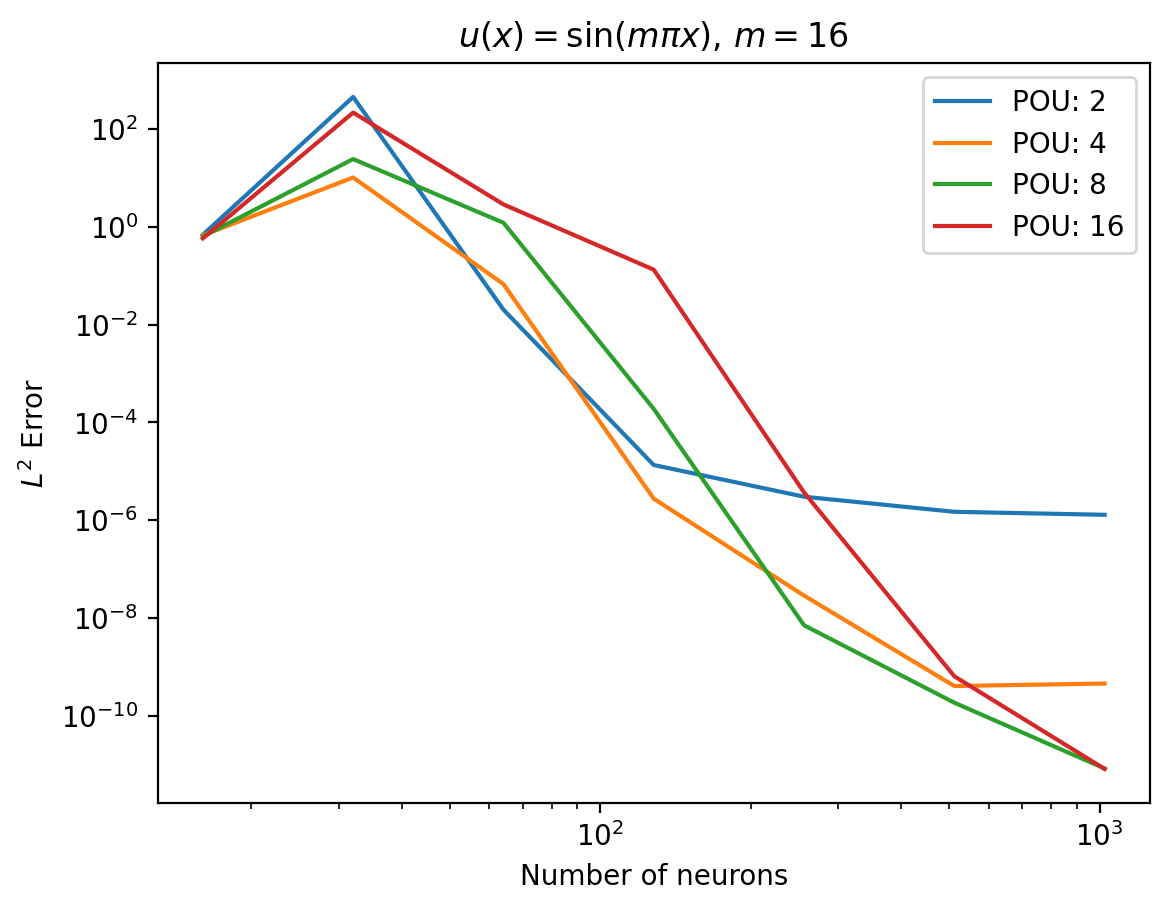

In [18]:
# analytical solution parameters
AA = 1
m = 16 
aa = m*np.pi
bb = 8.0*np.pi
lamb = 1 
activation = 'tanh'
k = 3 # if using tanh, k is not used 

def u(x):
    # return AA *  np.cos(aa * (x + 0.05)) + 2.0
    return AA * np.sin(aa * x)

def d2u_dx2(x):
    return -AA*(aa*aa) * np.sin(aa * x)

def F(points, lamb):
    return(- d2u_dx2(points)  + lamb * u(points)) # change 

func_name = "sin{}pix".format(m)
if __name__ == '__main__':
    lamb = 1 
    activation = 'tanh'
    relu_k = 2 # if using tanh, relu_k is not used 
    num_trials = 2
    R_m_list = [1] 
    POU_nums = [2,4,8,16]
    neuron_nums = [2**k for k in range(4,11)] 
    err_POU_nums = torch.zeros(len(POU_nums),len(neuron_nums))

    for R_m in R_m_list: # 0.5,1,2 
        print("Using R_m =", R_m)
        for i, M_p in enumerate(POU_nums):
            print("POU = ", M_p)
            for j, neuron in enumerate(neuron_nums):
                J_n = neuron // M_p  # the number of basis functions per PoU region
                Q = J_n  # the number of collocation points per PoU region
                # RFM_Error[i,0] = int(M_p * J_n)
                RFM_error_sum = 0 
                for trial in range(num_trials): # average over trials
                    models,w, RFM_Error, _ = main(M_p,J_n,Q,lamb,activation, k, print_res = False)
                    RFM_error_sum += RFM_Error
                err_POU_nums[i,j] = RFM_error_sum / num_trials
                print(err_POU_nums[i,j])
    folder = 'data/'
    filename = folder + "RFM_1dh1_Rm_{}_errs.pt".format(R_m)
    torch.save(err_POU_nums, filename)


# Plotting comparison between using POU and not using POU 
plt.figure(dpi = 200) 
plt.plot(neuron_nums[:], err_POU_nums[0,:], label = "POU: 2")
plt.plot(neuron_nums[:], err_POU_nums[1,:], label = "POU: 4")
plt.plot(neuron_nums[:], err_POU_nums[2,:], label = "POU: 8")
plt.plot(neuron_nums[:], err_POU_nums[3,:], label = "POU: 16") 

plt.yscale('log')
plt.xscale('log')
plt.xlabel("Number of neurons")
plt.ylabel("$L^2$ Error")
plt.title("$u(x) = \sin(m\pi x)$, $m = {}$".format(m))
plt.legend()
plt.show()
# plt.savefig("l21d-POU_vs_noPOU_sin16.png")

### without partition of unity  

Using R_m =  2


/var/folders/45/p1_q2drx75983lk7ph_1gx6mhpr5_w/T/ipykernel_53140/4274200674.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return(math.sqrt((X_max-X_min)*sum(epsilon*epsilon)/len(epsilon)))


[6.96310624e-01 5.94076272e+01 4.17168634e-03 5.89963158e-06
 2.54654431e-06 6.02121746e-07 1.27121800e-06]
Using R_m =  4
[6.96310624e-01 2.11737206e+04 1.63030009e-04 5.77152414e-09
 1.68546904e-10 3.12213097e-11 6.31521597e-11]
Using R_m =  8
[6.96310624e-01 1.26839097e+04 1.03263887e-01 1.43407763e-03
 1.03273541e-10 3.20425377e-13 1.86271491e-13]
Using R_m =  16
[6.96310624e-01 2.62204916e+03 7.93107634e+03 1.18684427e+00
 2.29072972e-08 2.62086979e-13 4.98375174e-14]


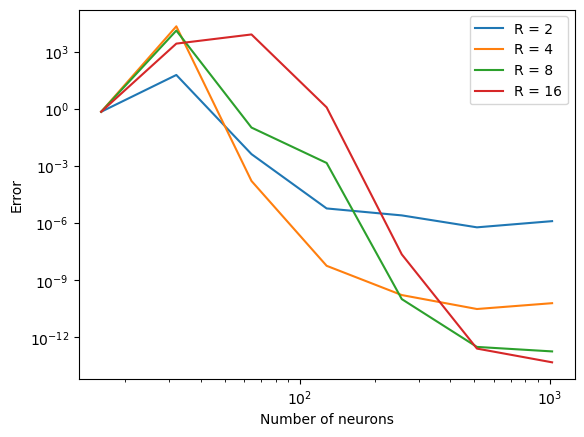

In [ ]:
# analytical solution parameters
AA = 1
m = 16 
aa = m*np.pi
lamb = 1 
activation = 'tanh'
relu_k = 3 # if using tanh, k is not used 

def u(x):
    # return AA *  np.cos(aa * (x + 0.05)) + 2.0
    return AA * np.sin(aa * x)

def d2u_dx2(x):
    return -AA*(aa*aa) * np.sin(aa * x)

def F(points, lamb):
    return(- d2u_dx2(points)  + lamb * u(points)) # change 

func_name = "sin{}pix".format(m)

if __name__ == '__main__':
    num_trials = 2   
    activation = 'tanh'
    relu_k = 3 # if using tanh, relu_k is not used 
    print_res = False 
    err_list_Rs = [] 
    R_m_list = [2,4,8,16]
    neuron_num_list = [2**k for k in range(4,11)] # 32,64,128,256,512
    err_R_values = np.zeros([len(R_m_list), len(neuron_num_list)]) # error for different values of R
    for i, R_m in enumerate(R_m_list): 
        print("Using R_m = ", R_m)
        print("========================================") 
        for j, neuron_num in enumerate(neuron_num_list): # the number of PoU regions
            M_p = 1   
            J_n = neuron_num 
            Q = J_n 
            RFM_Error_sum = 0 
            for trial in range(num_trials):
                models,w,RFM_Error, _= main(M_p,J_n,Q,lamb,activation=activation, k = relu_k,print_res= print_res)
                RFM_Error_sum += RFM_Error
            err_R_values[i,j] = RFM_Error_sum / num_trials  
        print(err_R_values[i,:])
err_R_values = torch.as_tensor(err_R_values) 

folder = 'data/'
filename = 'RFM_1dh1_noPOU_tanh_diff_Rm_sin{}pix.pt'.format(m) 
torch.save(err_R_values, folder + filename)

plt.figure(dpi = 100)

plt.plot(neuron_num_list, err_R_values[0,:], label = "R = 2")
plt.plot(neuron_num_list, err_R_values[1,:], label = "R = 4")
plt.plot(neuron_num_list, err_R_values[2,:], label = "R = 8")
plt.plot(neuron_num_list, err_R_values[3,:], label = "R = 16")
plt.yscale('log')
plt.xscale('log')
plt.xlabel("Number of neurons")
plt.ylabel("Error")
plt.legend()
plt.show()


## multiscale frequency test - no pou 

In [ ]:
# analytical solution parameters
AA = 1
a1 = 2.0*np.pi
a2 = 8.0*np.pi
a3 = 16.0*np.pi
lamb = 4
activation = 'tanh'
k = 3 # if using tanh, k is not used 

def u(x):
    return AA * np.sin(a1 * x) + 0.5 * AA * np.sin(a2 * x) + 0.5 * AA * np.sin(a3 * x) + 2.0 

def d2u_dx2(x):
    return -AA*(a1*a1)*np.sin(a1*x) - 0.5*AA*(a2*a2)*np.sin(a2*x) - 0.5*AA*(a3*a3)*np.sin(a3*x)

def F(points, lamb):
    return(- d2u_dx2(points)  + lamb * u(points)) # change 


if __name__ == '__main__':
    lamb = 4
     
    J = 50 # the number of basis functions per PoU region
    Q = 50 # the number of collocation pointss per PoU region
    print_res = False  
    num_diff_features = 5 
    num_trials = 1 
    RFM_Error = np.zeros([num_diff_features,3]) 
    err_list_trials =  np.zeros([num_diff_features,num_trials])
    err_list_Rs = [] 
    num_diff_features_list =[] 
    activation = 'tanh'
    relu_k = 3 
    R_m_list = [3,6,9, 12,24,48]
    for R_m in R_m_list: 
        print("Uinsg R_m = ", R_m)
        print("========================================") 
        for i in range(num_diff_features): # the number of PoU regions
            for trial in range(num_trials):
                M_p = 1   
                J_n = J * (2**i)*2 
                Q = int(3200/M_p)
                RFM_Error[i,0] = int(M_p * J_n)
                models,w,RFM_Error[i,1], RFM_Error[i,2] = main(M_p,J_n,Q,lamb,activation=activation, k = relu_k,print_res= print_res)
                err_list_trials[i,trial] = RFM_Error[i,1] 
                
        print(err_list_trials.mean(axis=1)) 
        err_list_Rs.append(err_list_trials.mean(axis=1))

num_diff_features_list = [100,200,400,800,1600]
print(output_results_Rs_latex(err_list_Rs, R_m_list, num_diff_features_list))

Uinsg R_m =  3


/var/folders/45/p1_q2drx75983lk7ph_1gx6mhpr5_w/T/ipykernel_33385/4274200674.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return(math.sqrt((X_max-X_min)*sum(epsilon*epsilon)/len(epsilon)))


[ 1.56869826 16.72712953  5.31966796  3.8324743   6.60723087]
Uinsg R_m =  6
[15.15987074 12.86179818  2.98136985  3.35195985 11.21995062]
Uinsg R_m =  9
[20.74379925  3.18224963 69.02755082 67.8830818   8.14286291]
Uinsg R_m =  12
[7.20025318e+00 7.52716986e+01 1.18714323e+01 4.99621971e-02
 6.02504010e-03]
Uinsg R_m =  24
[1.03111382e+01 1.30539365e+01 1.17959337e+00 7.39353726e-06
 1.43091053e-07]
Uinsg R_m =  48
[5.94295109e+01 4.41978453e+01 9.57468873e-01 2.76463775e-04
 2.55326840e-08]
\begin{tabular}{c|cccccc}
#Features $\backslash$ R & 3 & 6 & 9 & 12 & 24 & 48 \\
\hline
100 & 1.57e+00 & 1.52e+01 & 2.07e+01 & 7.20e+00 & 1.03e+01 & 5.94e+01 \\
200 & 1.67e+01 & 1.29e+01 & 3.18e+00 & 7.53e+01 & 1.31e+01 & 4.42e+01 \\
400 & 5.32e+00 & 2.98e+00 & 6.90e+01 & 1.19e+01 & 1.18e+00 & 9.57e-01 \\
800 & 3.83e+00 & 3.35e+00 & 6.79e+01 & 5.00e-02 & 7.39e-06 & 2.76e-04 \\
1600 & 6.61e+00 & 1.12e+01 & 8.14e+00 & 6.03e-03 & 1.43e-07 & 2.55e-08 \\
\end{tabular}


In [41]:
err_list_Rs
R_m_list
num_diff_features_list = [100,200]
print(output_results_Rs_latex(err_list_Rs, R_m_list, num_diff_features_list))

\begin{tabular}{c|cc}
#Features $\backslash$ R & 3 & 6 \\
\hline
100 & 7.57e+00 & 2.94e+00 \\
200 & 3.01e+00 & 5.40e+00 \\
\end{tabular}


IndexError: index 3 is out of bounds for axis 0 with size 3

In [48]:
M_p = 5 
Q = 10 
points = []
for n in range(M_p):
    x_min = (X_max-X_min)/M_p * n + X_min
    x_max = (X_max-X_min)/M_p * (n+1) + X_min
    points.append(np.linspace(x_min, x_max, Q+1).reshape([-1,1]))

In [50]:
points[0].shape  

(11, 1)